In [15]:
#récupération des données FUTURES BRENT et FUTURE WTI
import csv
fn = '../2bove/brent_data.csv'
csv_reader = csv.reader(open(fn,'r'))
datab=list(csv_reader)

fn='../2bove/wti_data.csv'
csv_reader = csv.reader(open(fn,'r'))
dataw=list(csv_reader)



In [52]:
# récupération des données
import pandas as pd 
import numpy as np

# Utilise index_col=0 pour que la date soit l'identifiant et pas une colonne de texte
wti = pd.read_csv('wti_data.csv', index_col=0)
brent = pd.read_csv('brent_data.csv', index_col=0)
wti['Close'] = pd.to_numeric(wti['Close'], errors='coerce')
brent['Close'] = pd.to_numeric(brent['Close'], errors='coerce')

# On crée le DataFrame
data = pd.DataFrame({
    'WTI': wti['Close'],
    'Brent': brent['Close']
})

# Supprimer les lignes vides 
data.dropna(inplace=True)

#boucle pour calculer le meilleur z score et la meilleure fenêtre de jour

profit = {} # Initialise le dictionnaire vide avant la boucle
sharpe={}
drawdown={}

# Calcul du spread une seule fois (gain de vitesse)
data['spread'] = data['WTI'] - data['Brent']
data['spread_diff'] = data['spread'].diff()

for i in range(5, 51, 5): # Fenêtres de 5 à 50 jours
    for k in range(10, 401, 5): # Z-score de 1 à 3.0
        z = k / 100
        
        # Calculs mobiles
        mean = data['spread'].rolling(i).mean()
        std = data['spread'].rolling(i).std()
        temp_Z = (data['spread'] - mean) / std

        # Signaux
        pos = pd.Series(0, index=data.index)
        pos.loc[temp_Z < -z] = 1
        pos.loc[temp_Z > z] = -1
        pos.loc[data['spread'].abs() < 3] = 0
        
        # On porte la position
        pos = pos.replace(to_replace=0, method='ffill')
        
        # Calcul de la performance
        strat_return = pos.shift(1) * data['spread_diff']
        profit_final = strat_return.sum()
        
        # Stockage du profit final (clé = tuple immuable)
        profit[(i, z)] = profit_final
        
        # calcul du sharpe ratio
        if strat_return.std() != 0:
            s = (strat_return.mean() / strat_return.std()) * np.sqrt(252)
        else:
            s = 0
        sharpe[(i, z)] = s

        #calcul  du max drawdown
        equity_curve = strat_return.cumsum()
        max_dd = (equity_curve - equity_curve.cummax()).min()
        drawdown[(i, z)] = max_dd
        
# On convertit le dico de profit en DataFrame
df_opti = pd.Series(profit).reset_index()
df_opti.columns = ['Fenetre', 'Z_score', 'Profit']

#on convertit le dico Drawdown en DataFrame
df_dd = pd.Series(drawdown).reset_index()
df_dd.columns = ['Fenetre', 'Z_score', 'Drawdown']
df_opti = df_opti.join(df_dd['Drawdown'])

# On convertit le dico du sharpe en DataFrame
df_risk = pd.Series(sharpe).reset_index()
df_risk.columns = ['Fenêtre', 'Z_score', 'Sharpe']
df_opti = df_opti.join(df_risk['Sharpe'])
top_5 = df_opti.sort_values(by='Profit', ascending=False).head(5)
print(top_5)

#calculons maintenant le plus gros sharpe ratio

top_5=df_opti.sort_values(by='Sharpe',ascending=False).head(5)
print(top_5)
#sur les données testées, on remarque qu'une zone robuste autour d'une fenêtre de 10 jours et Z-score de 2.05-2.25 maximise le profit (122$ environ)

C:\Users\2bove\AppData\Local\Temp\ipykernel_10560\2148656262.py:46: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  pos = pos.replace(to_replace=0, method='ffill')


     Fenetre  Z_score      Profit   Drawdown    Sharpe
205       15     2.45  131.119995 -10.650002  0.677845
118       10     2.05  122.919994 -12.070000  0.635384
119       10     2.10  122.360004 -12.070000  0.632485
122       10     2.25  121.500023 -12.070000  0.628032
206       15     2.50  121.360001 -12.070000  0.627307
     Fenetre  Z_score      Profit   Drawdown    Sharpe
205       15     2.45  131.119995 -10.650002  0.677845
118       10     2.05  122.919994 -12.070000  0.635384
119       10     2.10  122.360004 -12.070000  0.632485
122       10     2.25  121.500023 -12.070000  0.628032
206       15     2.50  121.360001 -12.070000  0.627307


In [2]:
#modèle utilisant des données contenu dans un fichier CSV local s'arrêtant à fin 2025
#on détermine les paramètres optimaux sur les données passées pour ensuite les tester sur les données de 2026

import pandas as pd 
import numpy as np

# Récupération des données
wti = pd.read_csv('wti_data.csv', index_col=0)
brent = pd.read_csv('brent_data.csv', index_col=0)

wti['Close'] = pd.to_numeric(wti['Close'], errors='coerce')
brent['Close'] = pd.to_numeric(brent['Close'], errors='coerce')

# On crée le DataFrame
data = pd.DataFrame({
    'WTI': wti['Close'],
    'Brent': brent['Close']
})

# Supprimer les lignes vides 
data.dropna(inplace=True)

# Boucle pour calculer le meilleur z score et la meilleure fenêtre de jour
profit = {} 
sharpe = {}
drawdown = {}

# Calcul du spread une seule fois
data['spread'] = data['WTI'] - data['Brent']
data['spread_diff'] = data['spread'].diff()

#Définition du coût de transaction par unité, couvrant spread + frais transaction, valeur 0.05$ est arbitraire
transaction_cost = 0.05 

for i in range(5, 51, 5): # Fenêtres de 5 à 50 jours
    for k in range(10, 401, 5): # Z-score de 1 à 3.0
        z = k / 100
        
        # Calculs mobiles
        mean = data['spread'].rolling(i).mean()
        std = data['spread'].rolling(i).std()
        temp_Z = (data['spread'] - mean) / std

        # Signaux
        pos = pd.Series(0, index=data.index)
        pos.loc[temp_Z < -z] = 1
        pos.loc[temp_Z > z] = -1
        pos.loc[data['spread'].abs() < 3] = 0
        
        # On porte la position
        pos = pos.replace(to_replace=0, method='ffill')
        pos = pos.fillna(0) # Sécurité pour le début du fichier
        
        # Calcul des coûts 
        # On regarde la différence de position d'un jour à l'autre pour voir si on a tradé
        trades = pos.diff().fillna(0).abs() 
        total_costs = trades * transaction_cost
        
        # Calcul de la performance Nette (Gain brut - Coûts)
        strat_return = (pos.shift(1) * data['spread_diff']) - total_costs
        
        profit_final = strat_return.sum()
        
        # Stockage du profit final
        profit[(i, z)] = profit_final
        
        # Calcul du sharpe ratio
        if strat_return.std() != 0:
            s = (strat_return.mean() / strat_return.std()) * np.sqrt(252)
        else:
            s = 0
        sharpe[(i, z)] = s

        # Calcul du max drawdown
        equity_curve = strat_return.cumsum()
        max_dd = (equity_curve - equity_curve.cummax()).min()
        drawdown[(i, z)] = max_dd
        
# On convertit le dico de profit en DataFrame
df_opti = pd.Series(profit).reset_index()
df_opti.columns = ['Fenetre', 'Z_score', 'Profit']

# On convertit le dico Drawdown en DataFrame
df_dd = pd.Series(drawdown).reset_index()
df_dd.columns = ['Fenetre', 'Z_score', 'Drawdown']
df_opti = df_opti.join(df_dd['Drawdown'])

# On convertit le dico du sharpe en DataFrame
df_risk = pd.Series(sharpe).reset_index()
df_risk.columns = ['Fenêtre', 'Z_score', 'Sharpe']
df_opti = df_opti.join(df_risk['Sharpe'])

# Affichage des meilleurs résultats
print("TOP 5 PAR PROFIT")
top_5_profit = df_opti.sort_values(by='Profit', ascending=False).head(5)
print(top_5_profit)

print("\nTOP 5 PAR SHARPE RATIO")
top_5_sharpe = df_opti.sort_values(by='Sharpe', ascending=False).head(5)
print(top_5_sharpe)

C:\Users\2bove\AppData\Local\Temp\ipykernel_17760\250487953.py:48: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  pos = pos.replace(to_replace=0, method='ffill')


--- TOP 5 PAR PROFIT ---
     Fenetre  Z_score      Profit   Drawdown    Sharpe
205       15     2.45  130.169995 -10.650002  0.673600
118       10     2.05  120.969994 -12.070000  0.625977
119       10     2.10  120.810004 -12.070000  0.625087
206       15     2.50  120.610001 -12.070000  0.624008
122       10     2.25  120.550023 -12.070000  0.623710

--- TOP 5 PAR SHARPE RATIO ---
     Fenetre  Z_score      Profit   Drawdown    Sharpe
205       15     2.45  130.169995 -10.650002  0.673600
118       10     2.05  120.969994 -12.070000  0.625977
119       10     2.10  120.810004 -12.070000  0.625087
206       15     2.50  120.610001 -12.070000  0.624008
122       10     2.25  120.550023 -12.070000  0.623710


C:\Users\2bove\AppData\Local\Temp\ipykernel_17760\1437918755.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start="2024-01-01", end=end_date, progress=False)['Close']
C:\Users\2bove\AppData\Local\Temp\ipykernel_17760\1437918755.py:56: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  data['position'] = data['position'].replace(to_replace=0, method='ffill')



 RÉSULTATS LIVE (2024 - Auj) 
Profit Final par baril : 11.35 $
Ratio de Sharpe : 1.07


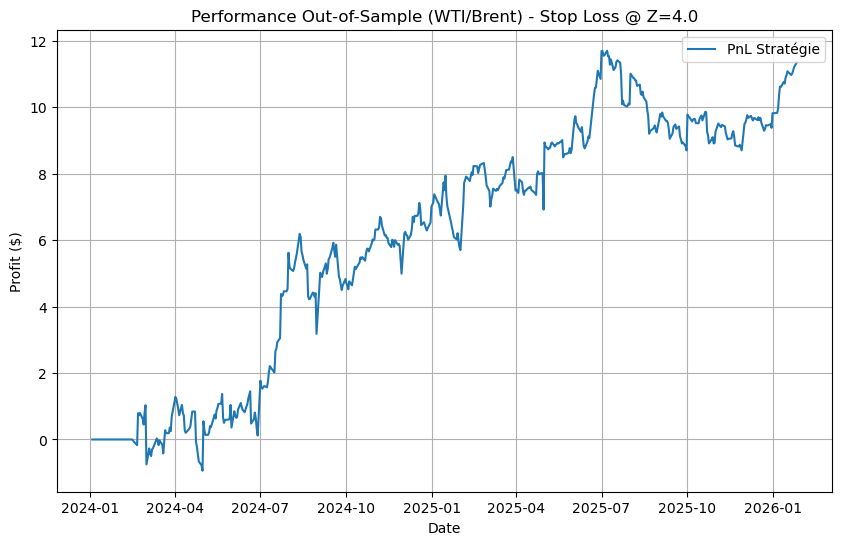

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime


#Téléchargement des données récentes
tickers = ['CL=F', 'BZ=F']
end_date = datetime.now().strftime('%Y-%m-%d') # Jusqu'à aujourd'hui

# On télécharge depuis 2024 pour avoir assez d'historique pour les moyennes mobiles
raw_data = yf.download(tickers, start="2024-01-01", end=end_date, progress=False)['Close']

# Nettoyage et alignement
data = pd.DataFrame()
data['WTI'] = raw_data['CL=F']
data['Brent'] = raw_data['BZ=F']
data.dropna(inplace=True) # On garde seulement les jours où les deux marchés cotent, brent et wti pas côtés aux mêmes places financières


#  PARAMÈTRES DE LA STRATÉGIE 
# 
best_window = 10  #paramètres trouvés précédemment, on prend pas la première car trop instable
best_z_entry = 2.05 
stop_loss_z = 4.0 #Si le Z-score dépasse 4, on coupe tout (c'est une anomalie de marché)
transaction_cost = 0.05 

# --- 3. CALCUL DES SIGNAUX ---
data['spread'] = data['WTI'] - data['Brent']
data['spread_diff'] = data['spread'].diff()

# Calculs mobiles sur la fenêtre choisie
mean = data['spread'].rolling(window=best_window).mean()
std = data['spread'].rolling(window=best_window).std()
data['z_score'] = (data['spread'] - mean) / std

# Initialisation des positions
data['position'] = 0 

# Conditions d'entrée (Mean Reversion)

data.loc[data['z_score'] < -best_z_entry, 'position'] = 1 
# On vend le spread si Z > +Seuil
data.loc[data['z_score'] > best_z_entry, 'position'] = -1 

# Conditions de sortie : Retour à la moyenne 
# Si le Z-score est proche de 0 (entre -0.5 et 0.5 par exemple), on sort
data.loc[data['z_score'].abs() < 0.5, 'position'] = 0


# On force la fermeture de la position pour ne pas tout perdre, si spread trop gros (forte agitation début 2026 au venezuela par exemple)
data.loc[data['z_score'].abs() > stop_loss_z, 'position'] = 0

# Propagation des positions (on garde la position tant qu'il n'y a pas de signal inverse ou de sortie)

data['position'] = data['position'].replace(to_replace=0, method='ffill')

# Si STOP LOSS ou TAKE PROFIT activé au-dessus, on doit s'assurer qu'il écrase le ffill

data.loc[data['z_score'].abs() > stop_loss_z, 'position'] = 0

data['position'] = data['position'].fillna(0) # Sécurité début de série

# CALCUL PERFORMANCE
trades = data['position'].diff().fillna(0).abs()
costs = trades * transaction_cost

# Stratégie PnL
data['strategy_return'] = (data['position'].shift(1) * data['spread_diff']) - costs

# Performance cumulée
data['cum_profit'] = data['strategy_return'].cumsum()

# AFFICHAGE RÉSULTATS
final_pnl = data['cum_profit'].iloc[-1]
sharpe_ratio = (data['strategy_return'].mean() / data['strategy_return'].std()) * np.sqrt(252)

print(f"\n RÉSULTATS LIVE (2024 - Auj) ")
print(f"Profit Final par baril : {final_pnl:.2f} $")
print(f"Ratio de Sharpe : {sharpe_ratio:.2f}")

# Graphique
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['cum_profit'], label='PnL Stratégie')
plt.title(f"Performance Out-of-Sample (WTI/Brent) - Stop Loss @ Z={stop_loss_z}")
plt.xlabel("Date")
plt.ylabel("Profit ($)")
plt.legend()
plt.grid(True)
plt.show()